# Composite: split-cookie + torchocolate

**Prerequisites:** Run `generate_mask_tables.ipynb` first. It writes names like `torchocolate_mc0.8_q0.9_nograd.pt` and `split-cookie_mc0.8_q0.9.pt` under each scene's `segment_results/` (see that notebook's final cell). Point the cells below at the `.pt` files you want, not necessarily the old `torchocolate.pt` / `split-cookie.pt` names.

**What this does:** Renders the split-cookie scene as background with the torch/chocolate
object from torchocolate composited into it, with controllable position/rotation/scale.

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import imageio
import numpy as np
import torch
from tqdm import tqdm
from argparse import ArgumentParser
from matplotlib import pyplot as plt
from arguments import ModelParams, PipelineParams, ModelHiddenParams
from utils.segment_utils import get_combined_args
from utils.transform_utils_torch import (
    init_dynamic_gaussians, render, to8b
)
import mmcv
from utils.params_utils import merge_hparams

%load_ext autoreload
%autoreload 2
print('Imports OK')


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Imports OK


## 1. Paths — edit these if needed

In [2]:
# ── Model paths ──
MODEL0      = './output/hypernerf/split-cookie'    # background scene (cookie table)
MODEL1      = './output/hypernerf/torchocolate'    # foreground object (plate + chocolate)
CFG_PATH    = './arguments/hypernerf/default.py'   # same config for both
# Descriptive tag for render output folder (set however you like).
RUN_TAG     = 'mc0.8_q0.9_nograd'
RENDER_PATH = f'./output/composite_{RUN_TAG}'

# ── Mask table paths (must match filenames from generate_mask_tables.ipynb) ──
# Cookie delete-mask, e.g. split-cookie_mc0.8_q0.9.pt after running Section B with those tunables.
MASK0 = './output/hypernerf/split-cookie/segment_results/split-cookie_mc0.8_q0.9.pt'

# Foreground insert mask, e.g. torchocolate_mc0.8_q0.9_nograd.pt from Section A defaults.
MASK1 = './output/hypernerf/torchocolate/segment_results/torchocolate_mc0.8_q0.9_nograd.pt'

os.makedirs(RENDER_PATH, exist_ok=True)

# Verify mask files exist
for label, path in [('MASK0 (required)', MASK0), ('MASK1 (required)', MASK1)]:
    if os.path.exists(path):
        print(f'  ✓ {label}: {path}')
    else:
        raise FileNotFoundError(f"✗ {label}: MISSING — run generate_mask_tables.ipynb first: {path}")


  ✓ MASK0 (required): ./output/hypernerf/split-cookie/segment_results/split-cookie.pt
  ✓ MASK1 (required): /home/ubuntu/new_sa4d/sa4d/output/hypernerf/torchocolate/segment_results/torchocolateBigger.pt


## 2. Load both scenes in scene mode

In [3]:
def load_scene(model_path, cfg_path):
    parser = ArgumentParser()
    model_p = ModelParams(parser, sentinel=True)
    hp = ModelHiddenParams(parser)
    parser.add_argument('--iteration', default=-1, type=int)
    parser.add_argument('--configs', type=str, default=cfg_path)

    args = get_combined_args(parser, model_path, 'scene')
    config = mmcv.Config.fromfile(args.configs)
    args = merge_hparams(args, config)
    args.object_masks  = False
    args.need_gt_masks = False

    gaussians, scene, background = init_dynamic_gaussians(
        model_p.extract(args), hp.extract(args), args.iteration
    )
    return gaussians, scene, background

print('Loading split-cookie...')
gaussians0, scene0, background = load_scene(MODEL0, CFG_PATH)

print('Loading torchocolate...')
gaussians1, scene1, _          = load_scene(MODEL1, CFG_PATH)

Loading split-cookie...
Looking for config file in ./output/hypernerf/split-cookie/cfg_args
Config file found at: ./output/hypernerf/split-cookie/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


135it [00:00, 71756.56it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 8.0361395  6.8197494 22.259563 ] [-7.0418544 -8.908094  11.280437 ]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 8.0361,  6.8197, 22.2596],
        [-7.0419, -8.9081, 11.2804]])
loading model from exists./output/hypernerf/split-cookie/point_cloud/iteration_14000
Init ./output/hypernerf/split-cookie finished

Loading torchocolate...
Looking for config file in ./output/hypernerf/torchocolate/cfg_args
Config file found at: ./output/hypernerf/torchocolate/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


174it [00:00, 68449.53it/s]

format finished
Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [47.76659775 31.60019684 94.26104736] [-54.118927   -65.01464844   9.57078719]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 47.7666,  31.6002,  94.2610],
        [-54.1189, -65.0146,   9.5708]])


loading model from exists./output/hypernerf/torchocolate/point_cloud/iteration_14000
Init ./output/hypernerf/torchocolate finished



## 3. Load mask tables

In [4]:
# Load plate+chocolate mask table (generated in generate_mask_tables.ipynb)
gaussians1.load_mask_table(MASK1)
print(
    f'torchocolate mask table: {gaussians1._mask_table.shape}  '
    f'(avg Gaussians selected per frame: {gaussians1._mask_table.float().sum(dim=1).mean():.0f})'
)

# Load cookie background DELETE mask (background scene already without the cookie)
gaussians0.load_mask_table(MASK0)
USE_COOKIE_MASK = True
print(f'split-cookie mask table: {gaussians0._mask_table.shape}')


torchocolate mask table: torch.Size([174, 246117])  (avg Gaussians selected per frame: 7546)
split-cookie mask table: torch.Size([135, 196777])


In [5]:
# Compute the object's center of mass in world space
with torch.no_grad():
    obj_center = gaussians1.get_xyz.mean(dim=0).cpu()
    print(f"Object center: {obj_center}")

# Formula: when you change scale, the center moves from (s_old * center) to (s_new * center)
# You need to compensate so the visible position stays the same
s_old = 0.5   # your working scale
s_new = 1.2   # your desired new scale

# This keeps the object in the same place while making it bigger
compensation = obj_center * (s_old - s_new)
base_offset  = torch.tensor([1.0, -1.8, 2.0])  # your working offset
motion_bias1 = base_offset + compensation

print(f"Compensation: {compensation}")
print(f"New motion_bias1: {motion_bias1}")

scales_bias1 = s_new

Object center: tensor([-2.0611, -8.5826, 32.8298])
Compensation: tensor([  1.4428,   6.0078, -22.9809])
New motion_bias1: tensor([  2.4428,   4.2078, -20.9809])


In [6]:
import torch

# --- Make sure the foreground transform vars exist (cell-order safe) ---
if 'motion_bias1' not in globals():
    motion_bias1 = torch.tensor([1.0, -1.8, 2.0])
if 'rotation_bias1' not in globals():
    rotation_bias1 = torch.tensor([0.0, 0.0, 0.0])
if 'scales_bias1' not in globals():
    scales_bias1 = 0.5

# Normalize types/devices
motion_bias1 = torch.as_tensor(motion_bias1, dtype=torch.float32, device='cuda')
rotation_bias1 = torch.as_tensor(rotation_bias1, dtype=torch.float32, device='cuda')
scales_bias1 = float(scales_bias1)

# Background: keep at identity
motion_bias0 = torch.zeros(3, device='cuda', dtype=torch.float32)
rotation_bias0 = torch.zeros(3, device='cuda', dtype=torch.float32)
scales_bias0 = 1.0

# Bias lists for [Background, Foreground]
motion_bias_list   = [motion_bias0,   motion_bias1]
rotation_bias_list = [rotation_bias0, rotation_bias1]
scales_bias_list   = [scales_bias0,   scales_bias1]

# Flags and gaussian list
static_flags = [False, False]
seg_flags    = [USE_COOKIE_MASK, True]
gaussians    = [gaussians0, gaussians1]

print('✅ Bias lists synchronized for [Background, Foreground]')


✅ Bias lists synchronized for [Background, Foreground]


## 4. Single-frame test — tune position, rotation and scale here

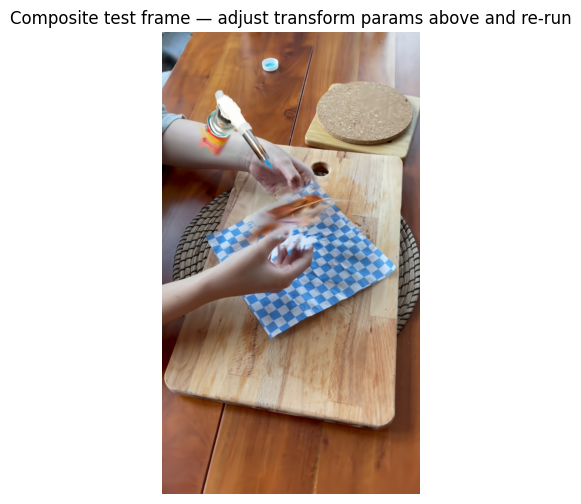

In [7]:
import torch

# ── gaussians list ──
# gaussians[0] = background (split-cookie)
# gaussians[1] = foreground object (torchocolate: plate + chocolate)

# ── Background transform (usually keep at identity) ──
scales_bias0   = 1.0
rotation_bias0 = torch.tensor([0.0, 0.0, 0.0])
motion_bias0   = torch.tensor([0.0, 0.0, 0.0])

# ── Foreground object transform — TUNE THESE ──
scales_bias1   = 0.5
rotation_bias1 = torch.tensor([0.0, 0.0, 0.0])
motion_bias1   = torch.tensor([1.0, -1.8, 2.0])

gaussians = [gaussians0, gaussians1]

# ── Pick a viewpoint from the cookie background ──
train_cams0 = scene0.getTrainCameras()
test_view   = train_cams0[0]
timestamp   = test_view.time

seg_flags    = [USE_COOKIE_MASK, True]
static_flags = [False, False]

with torch.no_grad():
    result = render(
        test_view, timestamp,
        gaussians,
        bg_color     = background,
        motion_bias  = [motion_bias0,   motion_bias1],
        rotation_bias= [rotation_bias0, rotation_bias1],
        scales_bias  = [scales_bias0,   scales_bias1],
        static       = static_flags,
        seg          = seg_flags,
        bg           = True
    )

plt.figure(figsize=(8, 6))
plt.imshow(to8b(result['render']).transpose(1,2,0))
plt.title('Composite test frame — adjust transform params above and re-run')
plt.axis('off')
plt.show()


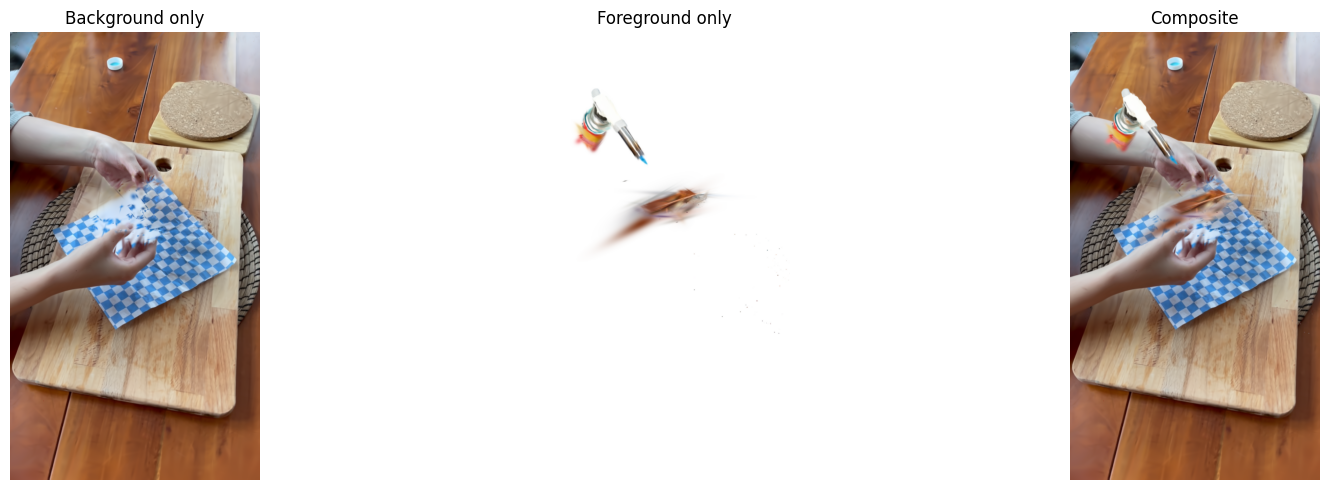

In [8]:
# ── Helper: show background / foreground / composite ──
with torch.no_grad():
    # background only
    result_bg = render(
        test_view, timestamp,
        [gaussians0], background,
        motion_bias=[motion_bias0], rotation_bias=[rotation_bias0],
        scales_bias=[scales_bias0], static=[False], seg=[USE_COOKIE_MASK], bg=True
    )

    # foreground only (skip bg in renderer)
    result_fg = render(
        test_view, timestamp,
        [gaussians0, gaussians1], background,
        motion_bias=[motion_bias0, motion_bias1],
        rotation_bias=[rotation_bias0, rotation_bias1],
        scales_bias=[scales_bias0, scales_bias1],
        static=[False, False], seg=[USE_COOKIE_MASK, True], bg=False
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(to8b(result_bg['render']).transpose(1,2,0))
axes[0].set_title('Background only'); axes[0].axis('off')
axes[1].imshow(to8b(result_fg['render']).transpose(1,2,0))
axes[1].set_title('Foreground only'); axes[1].axis('off')
axes[2].imshow(to8b(result['render']).transpose(1,2,0))
axes[2].set_title('Composite'); axes[2].axis('off')
plt.tight_layout()
plt.show()


## 5. Tune transforms interactively

Run the cell below repeatedly while adjusting `motion_bias1`, `rotation_bias1`, `scales_bias1`
until the torchocolate object is positioned where you want it in the scene.

**Tips:**
- `scales_bias1`: start at 0.3–0.5 since the two scenes have different scale units
- `motion_bias1`: move in small increments (0.1–0.5) to find the right position
- `rotation_bias1`: angles are in **radians** — `np.pi/4` = 45°, `np.pi/2` = 90°
- The object appears on top of the background because 3D Gaussians are sorted by depth during rasterization
- `static=[False, True]` can be used to freeze the torchocolate motion (only use cookie dynamics)

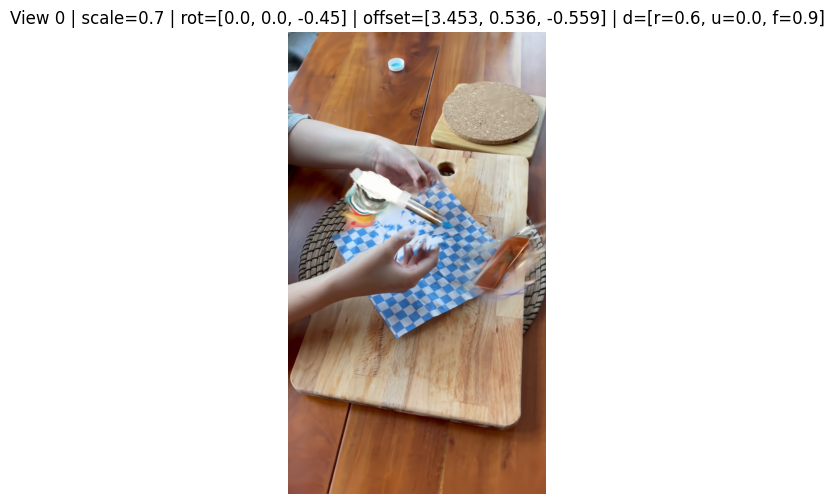

In [63]:
# ── Adjust these until the composite looks right ──
import torch
import torch.nn.functional as F

scales_bias1   = 0.7
rotation_bias1 = torch.tensor([0.0, 0.0, -0.45], device="cuda")   # [rx, ry, rz] radians

# Base world-space offset (your current values)
base_offset1   = torch.tensor([2.7, 0.7, 0.2], device="cuda")     # [x, y, z]

# Try different viewpoints: change this index (0 to len(train_cams0)-1)
VIEW_IDX  = 0
test_view = train_cams0[VIEW_IDX]

def camera_axes_world(cam):
    # world_view_transform is world->camera (W2C). Invert to get camera->world (C2W).
    W2C = cam.world_view_transform.cuda()
    C2W = torch.inverse(W2C)

    right   = C2W[:3, 0]
    up      = C2W[:3, 1]
    forward = -C2W[:3, 2]   # camera "forward" direction (common convention)
    return F.normalize(right, dim=0), F.normalize(up, dim=0), F.normalize(forward, dim=0)

right, up, forward = camera_axes_world(test_view)

# Camera-space nudges (meters-ish). Increase forward to bring it "toward camera"/closer to hands.
d_right   = 0.6
d_up      = 0.0
d_forward = 0.9   # try 0.1, 0.3, 0.6; flip sign if it moves the wrong way

motion_bias1 = base_offset1 + d_right * right + d_up * up + d_forward * forward

with torch.no_grad():
    result = render(
        test_view, test_view.time, gaussians, background,
        motion_bias  = [motion_bias0,   motion_bias1],
        rotation_bias= [rotation_bias0, rotation_bias1],
        scales_bias  = [scales_bias0,   scales_bias1],
        static       = static_flags,
        seg          = seg_flags,
        bg           = True
    )

plt.figure(figsize=(8,6))
plt.imshow(to8b(result['render']).transpose(1,2,0))
plt.title(
    f'View {VIEW_IDX} | scale={scales_bias1} | '
    f'rot={[round(float(x),3) for x in rotation_bias1.detach().cpu()]} | '
    f'offset={[round(float(x),3) for x in motion_bias1.detach().cpu()]} | '
    f'd=[r={d_right}, u={d_up}, f={d_forward}]'
)
plt.axis('off')
plt.show()

## 6. Render full video — Background drives timing

In [64]:
import torch
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")
print(f"Gaussians0 count: {gaussians0.get_xyz.shape[0]}")
print(f"Gaussians1 count: {gaussians1.get_xyz.shape[0]}")

GPU memory allocated: 0.27 GB
GPU memory reserved:  0.78 GB
Gaussians0 count: 196777
Gaussians1 count: 246117


In [65]:
import imageio.v2 as imageio
import gc

out_path = os.path.join(RENDER_PATH, 'composite_cookie_chocBigger.mp4')
video_cams0 = scene0.getVideoCameras()

# Write frames directly to disk — never accumulate in a list
writer = imageio.get_writer(out_path, fps=30, quality=8)

torch.cuda.empty_cache()
gc.collect()

print(f"Starting render of {len(video_cams0)} frames...")
print(f"GPU before render: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

with torch.no_grad():
    for idx, viewpoint in enumerate(tqdm(video_cams0)):
        result = render(
            viewpoint, viewpoint.time, gaussians, background,
            motion_bias  = [motion_bias0,   motion_bias1],
            rotation_bias= [rotation_bias0, rotation_bias1],
            scales_bias  = [scales_bias0,   scales_bias1],
            static       = static_flags,
            seg          = seg_flags,
            bg           = True
        )

        frame = to8b(result['render']).transpose(1,2,0)
        writer.append_data(frame)

        del result, frame

        if idx % 50 == 0:
            torch.cuda.empty_cache()
            if idx % 200 == 0:
                print(f"  Frame {idx}/{len(video_cams0)} | "
                      f"GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

writer.close()
torch.cuda.empty_cache()
print(f"Done → {out_path}")


Starting render of 134 frames...
GPU before render: 0.27 GB


  3%|▎         | 4/134 [00:00<00:09, 13.51it/s]

  Frame 0/134 | GPU: 0.25 GB


204it [00:09, 20.26it/s]                         

  Frame 200/134 | GPU: 0.25 GB


404it [00:20, 21.12it/s]

  Frame 400/134 | GPU: 0.25 GB


539it [00:26, 20.04it/s]


Done → ./output/composite_torchocolateBigger/composite_cookie_chocBigger.mp4


In [ ]:
# ── Option A: use video cameras from the COOKIE (background) scene ──
# The cookie scene's camera path drives the render.
# The torchocolate object is time-mapped to match via nearest-timestamp lookup.

video_cams0 = scene0.getVideoCameras()
print(f'Rendering {len(video_cams0)} frames from cookie scene camera path...')

render_images = []
with torch.no_grad():
    for idx, viewpoint in enumerate(tqdm(video_cams0)):
        result = render(
            viewpoint, viewpoint.time, gaussians, background,
            motion_bias  = [motion_bias0,   motion_bias1],
            rotation_bias= [rotation_bias0, rotation_bias1],
            scales_bias  = [scales_bias0,   scales_bias1],
            static       = static_flags,
            seg          = seg_flags,
            bg           = True
        )
        render_images.append(to8b(result['render']).transpose(1,2,0))

out_path = os.path.join(RENDER_PATH, 'composite_cookie_choc.mp4')
imageio.mimwrite(out_path, render_images, fps=30)
print(f'Saved {len(render_images)} frames → {out_path}')


Rendering 134 frames from cookie scene camera path...


414it [00:19, 20.75it/s]                                                        

In [ ]:
# ── Option B: use video cameras from the TORCHOCOLATE scene ──
# Cookie background is frozen at a fixed viewpoint while the choc dynamics play.

video_cams1   = scene1.getVideoCameras()
fixed_view    = train_cams0[0]   # fixed cookie viewpoint
print(f'Rendering {len(video_cams1)} frames from torchocolate camera path...')

render_images_b = []
with torch.no_grad():
    for idx, viewpoint in enumerate(tqdm(video_cams1)):
        # Use the torchocolate camera but timestamp from that scene
        result = render(
            viewpoint, viewpoint.time, gaussians, background,
            motion_bias  = [motion_bias0,   motion_bias1],
            rotation_bias= [rotation_bias0, rotation_bias1],
            scales_bias  = [scales_bias0,   scales_bias1],
            static       = static_flags,
            seg          = seg_flags,
            bg           = True
        )
        render_images_b.append(to8b(result['render']).transpose(1,2,0))

out_path_b = os.path.join(RENDER_PATH, 'composite_choc_cam.mp4')
imageio.mimwrite(out_path_b, render_images_b, fps=30)
print(f'Saved {len(render_images_b)} frames → {out_path_b}')


## 7. Optional: fixed-viewpoint render (no camera motion)
Useful for checking dynamics in isolation without camera path complexity.

In [ ]:
FIXED_VIEW_IDX = 0    # which cookie training camera to use as fixed viewpoint
fixed_view = train_cams0[FIXED_VIEW_IDX]

# Choose which scene's timestamps to iterate over
USE_CHOC_TIMESTAMPS = True   # True = torchocolate dynamics, False = cookie dynamics
timestamp_cams = scene1.getVideoCameras() if USE_CHOC_TIMESTAMPS else video_cams0

render_images_fx = []
print(f'Rendering {len(timestamp_cams)} frames at fixed viewpoint...')
with torch.no_grad():
    for viewpoint in tqdm(timestamp_cams):
        result = render(
            fixed_view, viewpoint.time, gaussians, background,
            motion_bias  = [motion_bias0,   motion_bias1],
            rotation_bias= [rotation_bias0, rotation_bias1],
            scales_bias  = [scales_bias0,   scales_bias1],
            static       = static_flags,
            seg          = seg_flags,
            bg           = True
        )
        render_images_fx.append(to8b(result['render']).transpose(1,2,0))

out_path_fx = os.path.join(RENDER_PATH, 'composite_fixed_view.mp4')
imageio.mimwrite(out_path_fx, render_images_fx, fps=30)
print(f'Saved → {out_path_fx}')


In [66]:
# ── Export composite PLY + composite mask for harmonization ──
# Writes:
#   1) <split-cookie>/point_cloud/iteration_14000/clean_chocolate.ply
#   2) <split-cookie>/segment_results/composite_inserted_choc.pt
#
# The exported PLY keeps the original split-cookie gaussian count, but makes the removed-cookie
# gaussians effectively invisible by forcing their opacity logits very negative. Then it appends
# the (plate+chocolate) gaussians from torchocolate WITH TRANSFORMS BAKED IN.

import os
import torch
import numpy as np
from plyfile import PlyData, PlyElement
from utils.transform_utils_torch import transform

EXPORT_PLY_PATH = os.path.join(MODEL0, 'point_cloud', 'iteration_14000', 'clean_chocolate_Bigger.ply')
EXPORT_MASK_PATH = os.path.join(MODEL0, 'segment_results', 'composite_inserted_choc_Bigger.pt')

# Background keep-mask from the delete mask table (True = keep)
if not hasattr(gaussians0, '_mask_table'):
    raise RuntimeError('Background gaussians0 has no _mask_table loaded (MASK0).')
if not hasattr(gaussians1, '_mask_table'):
    raise RuntimeError('Foreground gaussians1 has no _mask_table loaded (MASK1).')

bg_keep_any = gaussians0._mask_table.any(dim=0).bool()  # [N_bg]
fg_keep_any = gaussians1._mask_table.any(dim=0).bool()  # [N_fg]

N_bg = int(gaussians0._xyz.shape[0])
N_fg_sel = int(fg_keep_any.sum().item())

# ── Background tensors (same count as original, but hide removed ones) ──
xyz_bg = gaussians0._xyz.detach()
feat_dc_bg = gaussians0._features_dc.detach()
feat_rest_bg = gaussians0._features_rest.detach()
scaling_bg = gaussians0._scaling.detach()
rotation_bg = gaussians0._rotation.detach()
opacity_bg = gaussians0._opacity.detach().clone()

# Force removed-cookie gaussians invisible
removed = ~bg_keep_any
opacity_bg[removed] = -100.0

# ── Foreground tensors — APPLY TRANSFORMS before saving ──
# The transform() function operates on activated (not log-space) values,
# same as what get_state_at_time() returns before rasterization.
with torch.no_grad():
    xyz_fg_raw = gaussians1._xyz[fg_keep_any].detach().clone()
    scaling_fg_act = gaussians1.scaling_activation(gaussians1._scaling[fg_keep_any].detach().clone())
    rotation_fg_act = gaussians1.rotation_activation(gaussians1._rotation[fg_keep_any].detach().clone())

    # Bake the same transform used during composite rendering
    mb = motion_bias1.to('cuda') if not motion_bias1.is_cuda else motion_bias1
    rb = rotation_bias1.to('cuda') if not rotation_bias1.is_cuda else rotation_bias1
    sb = float(scales_bias1)

    xyz_fg_t, rotation_fg_t, scaling_fg_t = transform(
        xyz_fg_raw, rotation_fg_act, scaling_fg_act, sb, mb, rb
    )

    # Convert back to storage format:
    #   scaling: activated -> log-space (inverse of scaling_activation = exp)
    #   rotation: already a valid quaternion, store as-is (raw)
    scaling_fg_log = torch.log(scaling_fg_t.clamp(min=1e-8))
    rotation_fg_store = rotation_fg_t

feat_dc_fg = gaussians1._features_dc[fg_keep_any].detach()
feat_rest_fg = gaussians1._features_rest[fg_keep_any].detach()
opacity_fg = gaussians1._opacity[fg_keep_any].detach()

# ── Concatenate into composite arrays ──
xyz = torch.cat([xyz_bg, xyz_fg_t.cuda()], dim=0).cpu().numpy()
normals = np.zeros_like(xyz)

f_dc = torch.cat([
    feat_dc_bg.transpose(1, 2).flatten(start_dim=1),
    feat_dc_fg.transpose(1, 2).flatten(start_dim=1)
], dim=0).cpu().numpy()

f_rest = torch.cat([
    feat_rest_bg.transpose(1, 2).flatten(start_dim=1),
    feat_rest_fg.transpose(1, 2).flatten(start_dim=1)
], dim=0).cpu().numpy()

opacities = torch.cat([opacity_bg, opacity_fg], dim=0).cpu().numpy()
scale = torch.cat([scaling_bg, scaling_fg_log.cuda()], dim=0).cpu().numpy()
rot = torch.cat([rotation_bg, rotation_fg_store.cuda()], dim=0).cpu().numpy()

# Use the same attribute layout as the model's save_ply
dtype_full = [(a, 'f4') for a in gaussians0.construct_list_of_attributes()]
elements = np.empty(xyz.shape[0], dtype=dtype_full)
attributes = np.concatenate((xyz, normals, f_dc, f_rest, opacities, scale, rot), axis=1)
elements[:] = list(map(tuple, attributes))

os.makedirs(os.path.dirname(EXPORT_PLY_PATH), exist_ok=True)
PlyData([PlyElement.describe(elements, 'vertex')]).write(EXPORT_PLY_PATH)

# ── Build composite mask table ──
T = int(gaussians0._mask_table.shape[0])
N_total = int(xyz.shape[0])
inserted = torch.zeros((N_total,), dtype=torch.bool)
inserted[N_bg:] = True
mask_table = inserted.unsqueeze(0).repeat(T, 1)

mask_payload = {
    'mask_table': mask_table,
    'time_map': gaussians0._time_map if hasattr(gaussians0, '_time_map') else torch.linspace(0, 1, T),
}

os.makedirs(os.path.dirname(EXPORT_MASK_PATH), exist_ok=True)
torch.save(mask_payload, EXPORT_MASK_PATH)

print(f"✅ Wrote composite PLY:  {EXPORT_PLY_PATH}  (N_bg={N_bg}, N_fg_sel={N_fg_sel}, N_total={N_total})")
print(f"✅ Wrote composite mask: {EXPORT_MASK_PATH}  (shape={tuple(mask_table.shape)})")
print(f"   Transforms baked in: scale={sb}, rotation={[round(float(x),3) for x in rb]}, offset={[round(float(x),3) for x in mb]}")

✅ Wrote composite PLY:  ./output/hypernerf/split-cookie/point_cloud/iteration_14000/clean_chocolate_Bigger.ply  (N_bg=196777, N_fg_sel=9200, N_total=205977)
✅ Wrote composite mask: ./output/hypernerf/split-cookie/segment_results/composite_inserted_choc_Bigger.pt  (shape=(135, 205977))
   Transforms baked in: scale=0.7, rotation=[0.0, 0.0, -0.45], offset=[3.453, 0.536, -0.559]
